In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import scipy.stats as stats
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
from datetime import datetime
import os
import subprocess

pd.set_option('display.max_columns', None)

In [2]:
goodreads_export = f'./data/goodreads_library_export.csv'

if os.path.isfile(goodreads_export):
    os.remove(goodreads_export)
# Export my books
options = Options()
options.add_experimental_option("prefs", {
"download.prompt_for_download": False,
"download.directory_upgrade": True,
"safebrowsing.enabled": True
})

driver = webdriver.Chrome(options=options)
driver.get('https://www.goodreads.com/ap/signin?language=en_US&openid.assoc_handle=amzn_goodreads_web_na&openid.claimed_id=http%3A%2F%2Fspecs.openid.net%2Fauth%2F2.0%2Fidentifier_select&openid.identity=http%3A%2F%2Fspecs.openid.net%2Fauth%2F2.0%2Fidentifier_select&openid.mode=checkid_setup&openid.ns=http%3A%2F%2Fspecs.openid.net%2Fauth%2F2.0&openid.pape.max_auth_age=0&openid.return_to=https%3A%2F%2Fwww.goodreads.com%2Fap-handler%2Fsign-in')

print("Press 0 and Enter to continue...")
while True:
    time.sleep(5)
    user_input = input()
    if user_input:
        break

WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.CLASS_NAME, "homePrimaryColumn")))
driver.get('https://www.goodreads.com/review/import')
time.sleep(2)

goodreads_current_date = datetime.now().strftime('%m/%d/%Y')
file = driver.find_element(By.CLASS_NAME, 'fileList')
if goodreads_current_date not in file.text:
    export_button = driver.find_element(By.CLASS_NAME, 'js-LibraryExport')
    export_button.click()

WebDriverWait(driver, 60).until(EC.presence_of_element_located((By.CLASS_NAME, "fileList")))

while True:
    file = driver.find_element(By.CLASS_NAME, 'fileList')
    if goodreads_current_date in file.text:
        # find the link and click it
        link = file.find_element(By.TAG_NAME, 'a')
        link.click()
        time.sleep(1)
        break
    else:
        time.sleep(5)

driver.quit()

Press 0 and Enter to continue...


NoSuchWindowException: Message: no such window: target window already closed
from unknown error: web view not found
  (Session info: chrome=126.0.6478.127)
Stacktrace:
0   chromedriver                        0x000000010533aa80 chromedriver + 4385408
1   chromedriver                        0x000000010533338c chromedriver + 4354956
2   chromedriver                        0x0000000104f50b0c chromedriver + 281356
3   chromedriver                        0x0000000104f2baf0 chromedriver + 129776
4   chromedriver                        0x0000000104fb8314 chromedriver + 705300
5   chromedriver                        0x0000000104fcb438 chromedriver + 783416
6   chromedriver                        0x0000000104f87eec chromedriver + 507628
7   chromedriver                        0x0000000104f888c4 chromedriver + 510148
8   chromedriver                        0x000000010530243c chromedriver + 4154428
9   chromedriver                        0x0000000105306ea0 chromedriver + 4173472
10  chromedriver  

In [28]:
df1 = pd.read_csv('data/goodreads_library_export.csv')
df1['Original Publication Year'] = df1['Original Publication Year'].fillna(df1['Year Published'])

df1 = df1.drop(['Author l-f', 'Additional Authors', 'ISBN', 'ISBN13', 'Binding', 'My Review', 'Date Read', 'Date Added', 'Bookshelves with positions', 'Bookshelves', 'Exclusive Shelf', 'Spoiler', 'Private Notes', 'Year Published', 'Read Count', 'Owned Copies'], axis=1)

with open(r'data/book_ids.txt', 'w', encoding='utf-8') as f:
    for index, row in df1.iterrows():
        f.write(f'{row["Book Id"]}\n')

In [42]:
from requests import get
from datetime import datetime
import json
import os
import re
import time

from urllib.request import urlopen
from urllib.error import HTTPError
import bs4
import pandas as pd
from datetime import datetime
import glob


def get_genres(soup):
    genre_spans = soup.find_all('span', {'class': 'BookPageMetadataSection__genreButton'})
    genres = []
    for span in genre_spans:
        genre = span.find('span', {'class': 'Button__labelItem'}).text
        if genre != '...more':
            genres.append(genre)
    return genres

def get_series_name(soup):
    series_element = soup.find('h3', {'class': 'Text Text__title3 Text__italic Text__regular Text__subdued'})
    if series_element:
        series_name = series_element['aria-label']
        return series_name
    else:
        return None

def get_rating_distribution(soup):
    rating_bars = soup.find_all('div', {'class': 'RatingsHistogram__bar'})
    distribution_dict = {}
    for bar in rating_bars:
        star_rating = bar['aria-label'].split(' ')[0]
        total_ratings = bar.find('div', {'class': 'RatingsHistogram__labelTotal'}).text
        num_ratings = total_ratings.split(' ')[0]
        num_ratings = int(num_ratings.replace(',', ''))
        distribution_dict[star_rating] = num_ratings
    return distribution_dict

def get_id(bookid):
    pattern = re.compile("([^.-]+)")
    return int(pattern.search(bookid).group())
    
def get_title(soup):
    title = ' '.join(soup.find('h1', {'class': 'Text Text__title1'}).text.split())
    if title:
        return title
    else:
        return ""

In [44]:
def scrape_book(book_id):
    url = 'https://www.goodreads.com/book/show/' + book_id
    source = get(url)
    soup = bs4.BeautifulSoup(source, 'html.parser')

    try:
        # Extract the script tag and convert its content into a Python dictionary
        script_tag = soup.find('script', {'type': 'application/ld+json'})
        data = json.loads(script_tag.string)
    except AttributeError:
        print(f"============================= Skipping book {book_id} because the script tag was not found.")
        return None

    try:
        ratingCount = data['aggregateRating']['ratingCount'],
    except KeyError:
        ratingCount = 0
    try:
        reviewCount = data['aggregateRating']['reviewCount'],
    except KeyError:
        reviewCount = 0
    try:
        ratingValue = data['aggregateRating']['ratingValue'],
    except KeyError:
        ratingValue = 0
    
    return {'book_id':              get_id(book_id),
            'book_title':           get_title(soup),
            "book_series":          get_series_name(soup),
            'genres':               get_genres(soup),
            'num_ratings':          ratingCount,
            'num_reviews':          reviewCount,
            'average_rating':       ratingValue,
            'rating_distribution':  get_rating_distribution(soup)}

def condense_books(books_directory_path):
    books = []
    # Look for all the files in the directory and if they contain "book-metadata," then load them all and condense them into a single file
    for file_name in os.listdir(books_directory_path):
        if f'_metadata.json' in file_name:
            _book = json.load(open(books_directory_path + '/' + file_name, 'r')) #, encoding='utf-8', errors='ignore'))
            books.append(_book)
    return books

def delete_metadata():
    directory = './data/*metadata.json'
    files = glob.glob(directory)
    for f in files:
        os.remove(f)


start_time = datetime.now()

current_month = start_time.strftime('%m-%Y')
current_bookpath = 'data/book_ids.txt'

book_ids = [line.strip() for line in open(current_bookpath, 'r', encoding='utf-8') if line.strip()]
books_already_scraped = [file_name.replace(f'_metadata.json', '') for file_name in os.listdir('data') if file_name.endswith('.json')]

if os.path.isfile(f'data/{current_month}_goodreads_scraped.csv'):
    old_df = pd.read_csv(f'data/{current_month}_goodreads_scraped.csv')
    old_book_ids = old_df.book_id.tolist()
    old_book_ids = [str(id) for id in old_book_ids] 
    print(len(old_book_ids))
    books_to_scrape = [book_id for book_id in book_ids if book_id not in old_book_ids and book_id not in books_already_scraped]
    print(len(books_to_scrape))
else:
    books_to_scrape = [book_id for book_id in book_ids if book_id not in books_already_scraped]

condensed_books_path   = 'data' + f'/{current_month}_goodreads_scraped'

if books_to_scrape == []:
    delete_metadata()
    print('\nAll books already scraped\n')
else:
    for i, book_id in enumerate(books_to_scrape):
        try:
            print(str(datetime.now()) + ' ' + ': Scraping ' + book_id + '...')
            print(str(datetime.now()) + ' ' + ': #' + str(i+1+len(books_already_scraped)) + ' out of ' + str(len(book_ids)) + ' books')

            book = scrape_book(book_id)
            if book == None:
                continue
            else:
                # Add book metadata to file name to be more specific
                json.dump(book, open('data/' + book_id + f'_metadata.json', 'w'))

            print('=============================')

        except HTTPError as e:
            print(e)
            exit(0)

    books = condense_books('data')
    book_df = pd.DataFrame(books)

    if os.path.isfile(f'./data/{current_month}_goodreads_scraped.csv'):
        old_df = pd.read_csv(f'./data/{current_month}_goodreads_scraped.csv')
        book_df = pd.concat([old_df, book_df])
        book_df.to_csv(f"{condensed_books_path}.csv", index=False, encoding='utf-8')
    else:
        book_df.to_csv(f"{condensed_books_path}.csv", index=False, encoding='utf-8')
    
    delete_metadata()
    print(str(datetime.now()) + ' ' + f':\n\n🎉 Success! All book metadata scraped. 🎉\n\nMetadata files have been output to /{'data'}\nGoodreads scraping run time = ⏰ ' + str(datetime.now() - start_time) + ' ⏰')

2024-07-16 22:05:36.507939 : Scraping 19455573...
2024-07-16 22:05:36.508006 : #1 out of 560 books


TypeError: object of type 'Response' has no len()

### Once you have scraped for more info

In [12]:
current_month = datetime.now().strftime('%m-%Y')
df2 = pd.read_csv(f'./data/{current_month}_goodreads_scraped.csv')
df = df1.merge(df2, left_on='Book Id', right_on='book_id', how='inner')
df = df.drop(['Book Id', 'Title', 'average_rating'], axis=1)
df = df.rename(columns={'Author': 'author', 'Number of Pages': 'num_pages', 'Original Publication Year': 'year', 'My Rating': 'my_rating', 'Publisher': 'publisher', 'Average Rating': 'average_rating'})

df.rating_distribution = df.rating_distribution.apply(eval)
df.genres = df.genres.apply(eval)
df['age'] = int(datetime.now().strftime('%Y')) - df.year
median_age = df.age.median()
df.age = df.age.fillna(median_age)
median_num_pages = df.num_pages.median()
df.num_pages = df.num_pages.fillna(median_num_pages)
df.my_rating = df.my_rating.replace(0, np.nan)

def normalize_dict(d):
    max_value = max(d.values())
    return {f'num_{k}star_rating': v / max_value for k, v in d.items()}

df = pd.concat([df, df['rating_distribution'].apply(normalize_dict).apply(pd.Series)], axis=1)

# Elaborate rating distribution

### Normalize ratings

In [14]:
def fit_quadratic(row):
    x = np.array([1, 2, 3, 4, 5])
    a, b, c = np.polyfit(x, row, 2)
    return pd.Series([2*a, b, c])

# Apply the function to each row
coefficients = df[['num_1star_rating','num_2star_rating','num_3star_rating','num_4star_rating','num_5star_rating']].apply(fit_quadratic, axis=1)

# Create the new columns from the result
df['2a'], df['b'], df['c'] = coefficients[0], coefficients[1], coefficients[2]

scaler = MinMaxScaler()
df['num_ratings_log'] = np.log1p(df['num_ratings'])
df['age_log'] = np.log1p(df['age'])
df['num_pages_log'] = np.log1p(df['num_pages'])
df['average_rating_norm'] = scaler.fit_transform(df[['average_rating']])
df['average_rating_norm'] = df['average_rating_norm'] - 0.5

TypeError: loop of ufunc does not support argument 0 of type str which has no callable log1p method

In [ ]:
# # The idea is that if a book has only a few ratings, the Bayesian adjusted rating will be closer to the overall mean rating, while if a book has many ratings, the Bayesian adjusted rating will be closer to the book’s raw average rating.
# def bayesian_rating(df):
#   mean = df['average_rating'].mean()
#   std = df['average_rating'].std()
#   df['bayesian_rating'] = (df['average_rating'] * df['num_ratings'] + mean * std**2) / (df['num_ratings'] + std**2)
#   return df

# df = bayesian_rating(df)

In [ ]:
# Calculate the mean and standard deviation of the ratings
df['mean_rating'] = df[['num_1star_rating','num_2star_rating','num_3star_rating','num_4star_rating','num_5star_rating']].mean(axis=1)
df['std_rating'] = df[['num_1star_rating','num_2star_rating','num_3star_rating','num_4star_rating','num_5star_rating']].std(axis=1)

# Calculate the standard error of the mean
df['sem_score'] = df['std_rating'] / np.sqrt(df['num_ratings_log'])
df = df.drop(['mean_rating', 'std_rating'], axis=1)

In [ ]:
# # df['weighted_rating'] = (df.average_rating * df.num_ratings_log) / (df.num_pages_log)
# df['relative_weighted_rating'] = (df.average_rating_norm * df.num_ratings_log) / (df.num_pages_log)
# df['sem_rating'] = df.average_rating / (df.num_pages_log * df.sem_score)
df['relative_sem_rating'] = df.average_rating_norm / (df.num_pages_log * df.sem_score)

# df['trend_rating'] = (df['2a']-df.b+df.c)/df.num_pages_log
# df['trend_rating'] = (df['2a']-df.b)/df.num_pages_log # almost identical to the last
df['trend_rating'] = (df['2a'])/df.num_pages_log # favors promising books with fewer reviews

# Final ranking
# df['weighted_rank'] = df['weighted_rating'].rank(method='min')
# df['relative_weighted_rank'] = df['relative_weighted_rating'].rank(method='min')
# df['sem_rank'] = df['sem_rating'].rank(method='min')
df['relative_sem_rank'] = df['relative_sem_rating'].rank(method='min')
df['trend_rank'] = df['trend_rating'].rank(method='min')
df['final_rating'] = df.trend_rank + df.relative_sem_rank # + df.relative_weighted_rank

In [ ]:
df = df[['book_id', 'book_title', 'book_series', 'author', 'publisher', 'num_pages', 'year', 'my_rating', 'num_ratings', 'num_reviews', 'average_rating', 'rating_distribution', 'genres', 'relative_sem_rating', 'trend_rating','final_rating']]

In [ ]:
df.sort_values(by='final_rating', ascending=False).head(30)
# df.sort_values(by='relative_sem_rating', ascending=False)
# df.sort_values(by='trend_rating', ascending=False)
df.loc[df['my_rating'].isna(), :].sort_values(by='final_rating', ascending=False).head(30)
# df[df['my_rating'].isna() == False].sort_values(by='final_rating', ascending=False).head(30)

,book_id,book_title,book_series,author,publisher,num_pages,year,my_rating,num_ratings,num_reviews,average_rating,rating_distribution,genres,relative_sem_rating,trend_rating,final_rating
439,464260,The Fire Next Time,NaN,James Baldwin,Vintage,106.0,1963.0,NaN,100945,9151,4.54,"{'5': 65491, '4': 27245, '3': 6448, '2': 1159,...","[Nonfiction, Classics, Essays, Race, History, ...",0.650621,0.042427,1065.0
157,50196744,Know My Name,NaN,Chanel Miller,Viking,384.0,2019.0,NaN,201498,27899,4.71,"{'5': 155253, '4': 35780, '3': 8415, '2': 1538...","[Nonfiction, Memoir, Audiobook, Feminism, Biog...",0.692185,0.039782,1064.0
430,20342617,Just Mercy,NaN,Bryan Stevenson,One World,336.0,2014.0,NaN,232542,25777,4.63,"{'5': 166106, '4': 51750, '3': 10935, '2': 231...","[Nonfiction, Memoir, Social Justice, Race, Pol...",0.633828,0.038293,1059.0
155,23463279,Designing Data-Intensive Applications,NaN,Martin Kleppmann,O'Reilly,562.0,2015.0,NaN,8424,771,4.71,"{'5': 6455, '4': 1597, '3': 297, '2': 48, '1':...","[Programming, Technology, Computer Science, So...",0.558379,0.037478,1057.0
175,50611052,The Rise and Triumph of the Modern Self: Cultu...,NaN,Carl R. Trueman,Crossway,432.0,2020.0,NaN,4950,1020,4.58,"{'5': 3374, '4': 1208, '3': 261, '2': 73, '1':...","[Philosophy, History, Nonfiction, Cultural, Ch...",0.464651,0.034963,1039.0
444,5055380,Jiu-Jitsu University,NaN,Saulo Ribeiro,Victory Belt Publishing,368.0,2008.0,NaN,1304,59,4.58,"{'5': 886, '4': 316, '3': 81, '2': 13, '1': 8}","[Martial Arts, Nonfiction, Sports, Fitness, He...",0.438741,0.035380,1034.0
107,426504,Ficciones,NaN,Jorge Luis Borges,Grove Press,174.0,1944.0,NaN,68128,4257,4.42,"{'5': 40784, '4': 18118, '3': 6752, '2': 1799,...","[Fiction, Short Stories, Magical Realism, Fant...",0.457837,0.033569,1034.0
10,30008981,Atmamun: The Path To Achieving The Bliss Of Th...,NaN,Kapil Gupta MD,NaN,137.0,2016.0,NaN,875,77,4.47,"{'5': 547, '4': 220, '3': 86, '2': 13, '1': 9}","[Philosophy, Spirituality, Self Help, Nonficti...",0.419176,0.037474,1031.0
193,33986067,Deep Learning with Python,NaN,François Chollet,Manning,350.0,2017.0,NaN,1265,128,4.57,"{'5': 847, '4': 321, '3': 78, '2': 12, '1': 7}","[Programming, Artificial Intelligence, Compute...",0.432546,0.035081,1031.0
47,1617,Night,Book 1 in the The Night Trilogy series,Elie Wiesel,Hill & Wang,120.0,1956.0,NaN,1248527,38057,4.37,"{'5': 698843, '4': 372712, '3': 134190, '2': 2...","[Nonfiction, Classics, Memoir, Holocaust, Biog...",0.478789,0.032218,1030.0


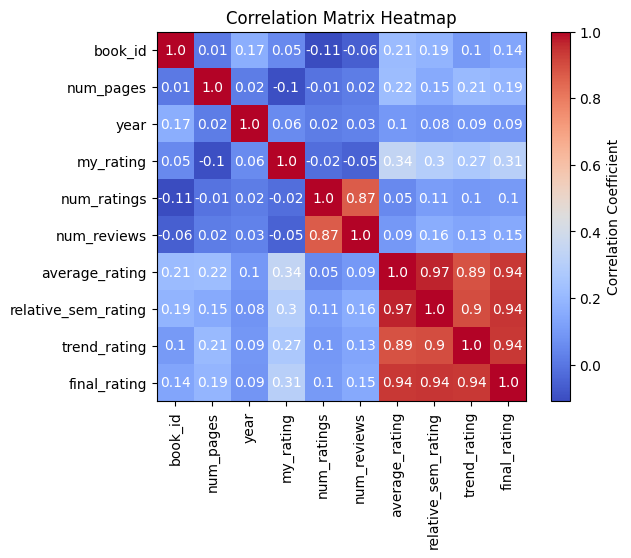

In [ ]:
correlation_matrix = df.drop(['genres', 'rating_distribution', 'author', 'book_title', 'book_series', 'publisher'], axis=1).corr()

plt.imshow(correlation_matrix, cmap='coolwarm')  # Adjust 'coolwarm' for preferred colormap

# Add labels and title
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Matrix Heatmap')

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = plt.text(j, i, round(correlation_matrix.iloc[i, j], 2),
                       ha="center", va="center", color="w")

# Display the plot
plt.show()

In [ ]:
# correlation_matrix.sort_values(by='2a', ascending=False)

# Elaborate genres and rating_dist columns

In [ ]:
df_exploded = df.explode('genres')
genres_dummies = pd.get_dummies(df_exploded['genres'])

df_exploded = pd.concat([df_exploded, genres_dummies], axis=1)

agg_dict = {col: 'first' for col in df_exploded.columns.difference(['genres']+list(genres_dummies.columns))}
agg_dict.update({col: 'sum' for col in genres_dummies.columns})

df_genres = df_exploded.groupby('book_id', as_index=False).agg(agg_dict)


In [ ]:
# drop uncommon genres
mean_genres = pd.Series(genres_dummies.mean(), index=genres_dummies.columns)
for column in df_genres.columns:
    if column in mean_genres.index and mean_genres.loc[column] < mean_genres.mean():
        df_genres = df_genres.drop(column, axis=1)

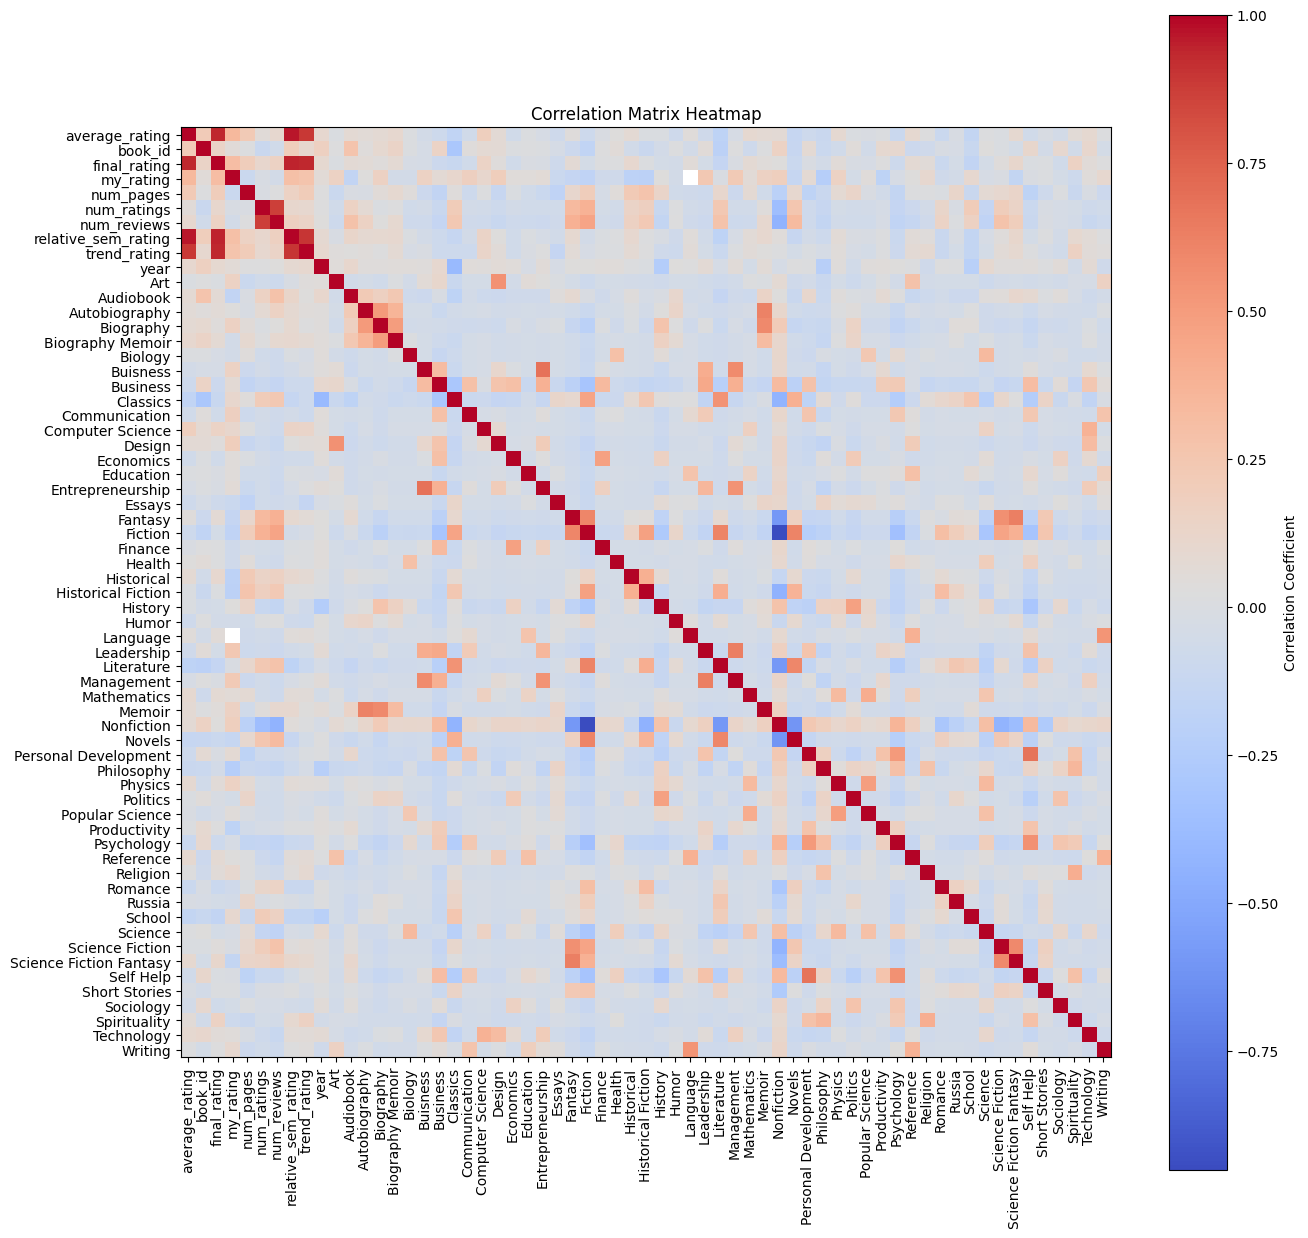

In [ ]:
correlation_matrix = df_genres.drop(['rating_distribution', 'author', 'book_title', 'book_series', 'publisher'], axis=1).corr()
plt.figure(figsize=(15,15))
plt.imshow(correlation_matrix, cmap='coolwarm')  # Adjust 'coolwarm' for preferred colormap

# Add labels and title
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Matrix Heatmap')

# Display the plot
plt.show()

In [ ]:
correlation_matrix.sort_values(by='my_rating', ascending=False).head(30)


,average_rating,book_id,final_rating,my_rating,num_pages,num_ratings,num_reviews,relative_sem_rating,trend_rating,year,Art,Audiobook,Autobiography,Biography,Biography Memoir,Biology,Buisness,Business,Classics,Communication,Computer Science,Design,Economics,Education,Entrepreneurship,Essays,Fantasy,Fiction,Finance,Health,Historical,Historical Fiction,History,Humor,Language,Leadership,Literature,Management,Mathematics,Memoir,Nonfiction,Novels,Personal Development,Philosophy,Physics,Politics,Popular Science,Productivity,Psychology,Reference,Religion,Romance,Russia,School,Science,Science Fiction,Science Fiction Fantasy,Self Help,Short Stories,Sociology,Spirituality,Technology,Writing
my_rating,0.343882,0.053262,0.310248,1.000000,-0.098307,-0.019634,-0.050588,0.297441,0.268113,0.058665,0.153427,-0.152611,0.029035,0.158563,-0.049000,-0.049000,0.153427,0.069740,0.103215,0.175425,0.107801,0.189126,0.041844,0.041844,0.059950,-0.099916,-0.141066,-0.171071,-0.069740,-0.069740,-0.184421,-0.190155,0.029035,-0.049000,NaN,0.235051,-0.006585,0.219815,0.059950,0.158563,0.180876,-0.134168,0.070406,-0.229216,0.153427,-0.040483,0.041844,-0.177663,-0.024584,0.031487,0.097428,-0.069740,-0.049000,0.097428,-0.026074,-0.011560,-0.145175,-0.011059,0.005731,-0.040483,-0.087105,0.041844,0.097428
average_rating,1.000000,0.212879,0.935420,0.343882,0.221574,0.052566,0.094706,0.966048,0.890515,0.095846,-0.005456,0.077348,0.056403,0.073774,0.095117,0.004508,-0.044698,-0.082372,-0.161762,-0.060418,0.184215,0.063091,-0.063655,0.001767,-0.024971,-0.081039,0.033297,-0.086761,-0.006197,0.026591,0.076109,-0.002609,-0.004812,-0.080916,0.041677,-0.074592,-0.179111,-0.027130,0.092052,0.071515,0.069967,-0.134242,-0.083637,-0.110709,0.080464,-0.006046,-0.011609,0.003125,-0.104107,0.086394,0.019106,-0.105023,-0.020888,-0.148656,0.012540,-0.003945,0.091080,-0.063244,-0.018047,-0.044380,0.059350,0.087129,0.015732
final_rating,0.935420,0.137178,1.000000,0.310248,0.192829,0.100905,0.146381,0.940417,0.935936,0.088536,-0.003445,0.063197,0.055397,0.036925,0.072856,-0.025698,-0.036383,-0.093200,-0.116979,-0.065103,0.143206,0.034116,-0.059470,-0.006341,-0.018765,-0.081160,0.066352,-0.040772,0.015996,0.011383,0.093938,0.007394,-0.043856,-0.047651,0.049016,-0.043486,-0.142596,-0.008489,0.072477,0.046504,0.027693,-0.098544,-0.008143,-0.048527,0.054039,-0.018557,-0.025840,0.018983,-0.087231,0.077390,0.048709,-0.101299,-0.039270,-0.151765,-0.040724,0.035831,0.110118,-0.002114,0.002967,-0.059926,0.146781,0.054131,0.018609
relative_sem_rating,0.966048,0.186359,0.940417,0.297441,0.151030,0.107390,0.162143,1.000000,0.899510,0.084354,-0.017599,0.116481,0.084669,0.088718,0.096912,-0.003115,-0.049115,-0.083878,-0.130736,-0.049406,0.138103,0.031791,-0.066087,-0.005661,-0.029705,-0.058952,0.088598,-0.046836,-0.001684,0.015187,0.096509,0.010494,-0.016968,-0.069052,0.042573,-0.057127,-0.177366,-0.027791,0.055839,0.097577,0.042137,-0.125598,-0.049123,-0.089809,0.058957,-0.006789,-0.016661,0.010383,-0.097781,0.053674,0.039206,-0.105170,-0.015164,-0.148105,-0.024690,0.039162,0.110356,-0.042815,0.016608,-0.050530,0.089995,0.057121,0.019499
trend_rating,0.890515,0.098547,0.935936,0.268113,0.207160,0.097477,0.134635,0.899510,1.000000,0.093192,0.032158,0.030742,0.043840,0.020735,0.070548,-0.022674,-0.011191,-0.082931,-0.085204,-0.089394,0.125015,0.048638,-0.063910,-0.007909,0.019590,-0.137696,0.062095,-0.026566,0.008725,0.004745,0.075229,0.017740,-0.067500,-0.082521,0.051543,-0.041075,-0.102881,0.006354,0.054863,0.029285,0.010045,-0.041370,0.000347,-0.030726,0.043266,-0.023270,-0.038807,0.011655,-0.093295,0.067784,0.083321,-0.108644,-0.037011,-0.144049,-0.041183,0.056043,0.087893,0.012380,-0.033325,-0.059721,0.161465,0.054726,0.034613
Leadership,-0.074592,0.054796,-0.043486,0.235051,-0.087158,-0.068362,-0.097302,-0.057127,-0.041075,0.068168,-0.066602,-0.047312,-0.062118,0.013826,-0.060562,-0.063642,0.409427,0.432315,-0.158169,0.212591,-0.053959,-0.031205,-0.042279,-0.060562,0.346982,-0.065136,-0.096488

In [ ]:
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(df.sort_values(by='2a', ascending=False))